# Swiggy Restaurant Data — Exploratory Data Analysis (EDA)

## Project Objective
Analyze the Swiggy restaurant dataset to understand:
- Restaurant and city distribution
- Pricing patterns
- Customer ratings and popularity
- Food-type preferences
- Delivery-time patterns
- Relationships between price, ratings, popularity, and delivery time
- Potential business insights for customers and food-delivery platforms

**Dataset:** `swiggy.csv`


In [1]:
# Import required libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Load dataset
df = pd.read_csv("/content/swiggy.csv")

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())


Dataset shape: 8,680 rows × 10 columns


,ID,Area,City,Restaurant,Price,Avg ratings,Total ratings,Food type,Address,Delivery time
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,"Mughlai,Lucknowi",5Th Block,56
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250.0,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57
4,249,Indiranagar,Bangalore,Nh8,350.0,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63


## 1. Dataset Overview

In [2]:
# Basic structure
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nFirst 10 rows:")
display(df.head(10))

print("\nRandom sample:")
display(df.sample(min(5, len(df)), random_state=42))


Shape: (8680, 10)

Column names:
['ID', 'Area', 'City', 'Restaurant', 'Price', 'Avg ratings', 'Total ratings', 'Food type', 'Address', 'Delivery time']

Data types:


,dtype
ID,int64
Area,object
City,object
Restaurant,object
Price,float64
Avg ratings,float64
Total ratings,int64
Food type,object
Address,object
Delivery time,int64



First 10 rows:


,ID,Area,City,Restaurant,Price,Avg ratings,Total ratings,Food type,Address,Delivery time
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,"Mughlai,Lucknowi",5Th Block,56
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250.0,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57
4,249,Indiranagar,Bangalore,Nh8,350.0,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63
5,254,Indiranagar,Bangalore,Treat,800.0,4.5,100,"Mughlai,North Indian",100 Feet Road,56
6,258,Indiranagar,Bangalore,Chinita Real Mexican Food,1000.0,4.5,500,"Mexican,Beverages,Salads",Double Road,53
7,263,Koramangala,Bangalore,Cupcake Noggins - Cakespastries And Desserts,150.0,4.3,100,"Desserts,British,Bakery,Pizzas,Snacks",4Th Block,57
8,267,Domlur,Bangalore,Tea Brew,350.0,4.1,100,"American,Italian,Beverages,Continental,Chinese...",Double Road,57
9,308,Koramangala,Bangalore,Bangaliana,300.0,4.0,500,Bengali,7Th Block,57



Random sample:


,ID,Area,City,Restaurant,Price,Avg ratings,Total ratings,Food type,Address,Delivery time
3217,316772,Madhavaram,Chennai,Idlicurry,150.0,4.0,100,South Indian,Perambur,66
7448,118742,Isanpur,Ahmedabad,Kutchi Karnavati,100.0,3.5,20,"Fast Food,Pizzas,Chinese,Snacks",Isanpur,43
2816,280507,T. Nagar,Chennai,Courtyard By Marriott,700.0,4.3,100,"Biryani,Combo,Pizzas,Home Food,Indian,Continen...",T Nagar,67
6984,54473,George Town,Chennai,Hotel Shiva Shagar,450.0,4.1,100,"Beverages,North Indian,South Indian",Park Town,36
3710,347069,Kothrud,Pune,Fried Chicken Destination,200.0,4.2,500,"Fast Food,American,Snacks",Kothrud,58


## 2. Data Quality Check

In [3]:
# Missing values and duplicates
quality = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().mean() * 100).round(2),
    "Unique Values": df.nunique(),
    "Data Type": df.dtypes.astype(str)
})

display(quality)

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate IDs:", df["ID"].duplicated().sum())


,Missing Values,Missing %,Unique Values,Data Type
ID,0,0.0,8680,int64
Area,0,0.0,833,object
City,0,0.0,9,object
Restaurant,0,0.0,7865,object
Price,0,0.0,120,float64
Avg ratings,0,0.0,30,float64
Total ratings,0,0.0,8,int64
Food type,0,0.0,3734,object
Address,0,0.0,2339,object
Delivery time,0,0.0,81,int64


Duplicate rows: 0
Duplicate IDs: 0


In [4]:
# Descriptive statistics
display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,8680.0,NaN,NaN,NaN,244812.071429,158671.617188,211.0,72664.0,283442.0,393425.25,466928.0
Area,8680,833,Rohini,257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,8680,9,Kolkata,1346,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Restaurant,8680,7865,La Pino'Z Pizza,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,8680.0,NaN,NaN,NaN,348.44447,230.940074,0.0,200.0,300.0,400.0,2500.0
Avg ratings,8680.0,NaN,NaN,NaN,3.655104,0.647629,2.0,2.9,3.9,4.2,5.0
Total ratings,8680.0,NaN,NaN,NaN,156.634793,391.448014,20.0,50.0,80.0,100.0,10000.0
Food type,8680,3734,Indian,389,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Address,8680,2339,Rohini,229,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delivery time,8680.0,NaN,NaN,NaN,53.967051,14.292335,20.0,44.0,53.0,64.0,109.0


## 3. Univariate Analysis — Numerical Variables

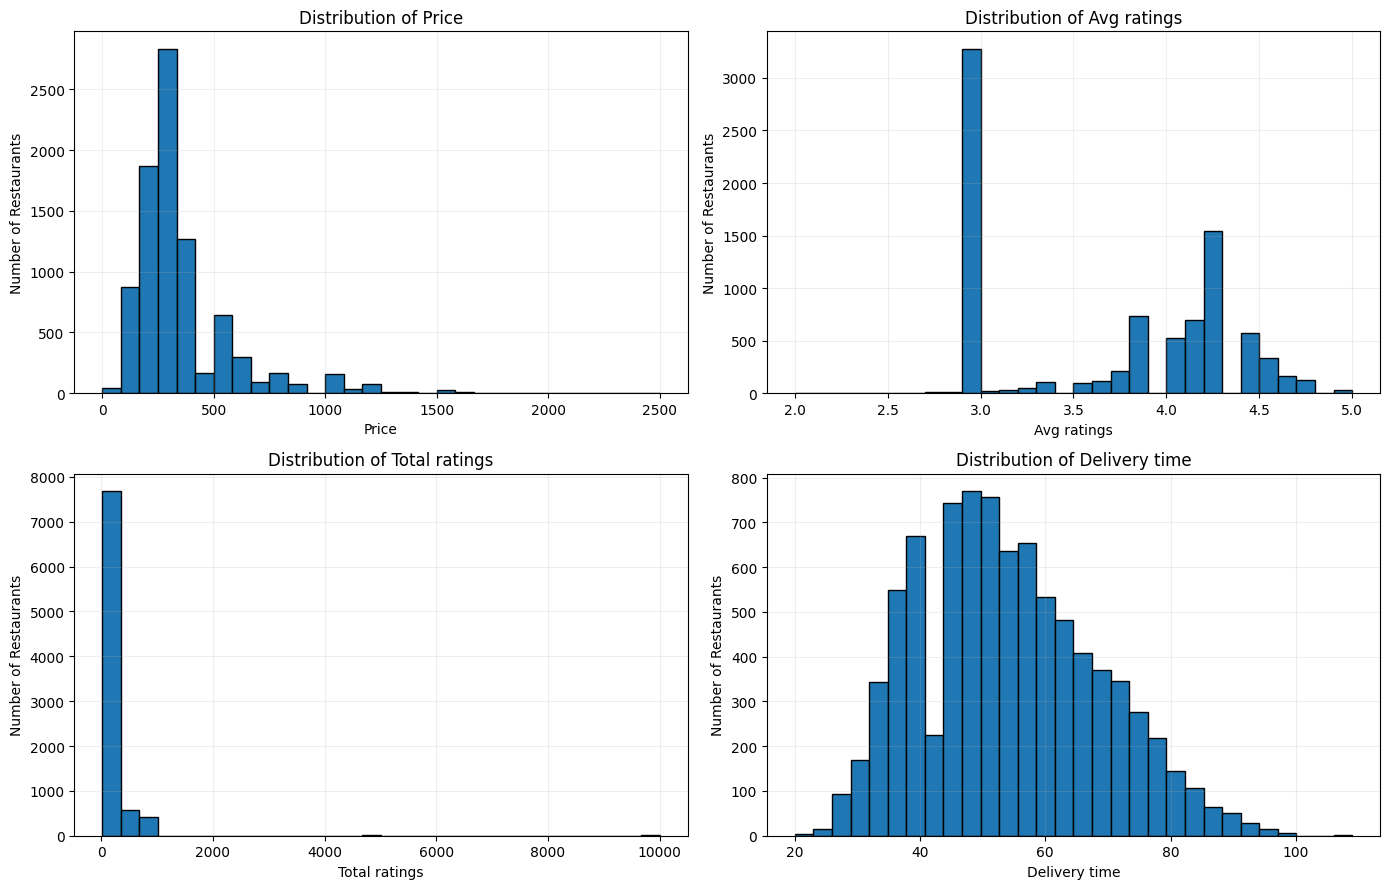

In [5]:
numeric_cols = ["Price", "Avg ratings", "Total ratings", "Delivery time"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col].dropna(), bins=30, edgecolor="black")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Number of Restaurants")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


## 4. Price Analysis

In [6]:
print("Price statistics:")
display(df["Price"].describe())

price_summary = df["Price"].agg(["min", "mean", "median", "max"]).round(2)
display(price_summary.to_frame("Value"))


Price statistics:


,Price
count,8680.000000
mean,348.444470
std,230.940074
min,0.000000
25%,200.000000
50%,300.000000
75%,400.000000
max,2500.000000


,Value
min,0.00
mean,348.44
median,300.00
max,2500.00


,Restaurants
Price Band,
≤200,2756
201–400,4137
401–600,1080
601–800,289
801–1000,231
>1000,187


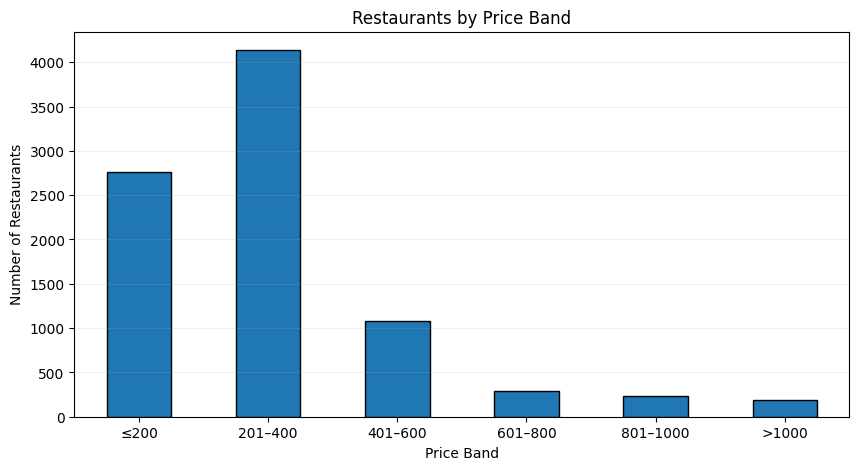

In [7]:
# Price bands
price_bins = [-np.inf, 200, 400, 600, 800, 1000, np.inf]
price_labels = ["≤200", "201–400", "401–600", "601–800", "801–1000", ">1000"]

df["Price Band"] = pd.cut(df["Price"], bins=price_bins, labels=price_labels)

price_band = df["Price Band"].value_counts().sort_index()
display(price_band.to_frame("Restaurants"))

plt.figure(figsize=(10, 5))
price_band.plot(kind="bar", edgecolor="black")
plt.title("Restaurants by Price Band")
plt.xlabel("Price Band")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)
plt.show()


## 5. Rating Analysis

,Value
count,8680.00
mean,3.66
std,0.65
min,2.00
25%,2.90
50%,3.90
75%,4.20
max,5.00


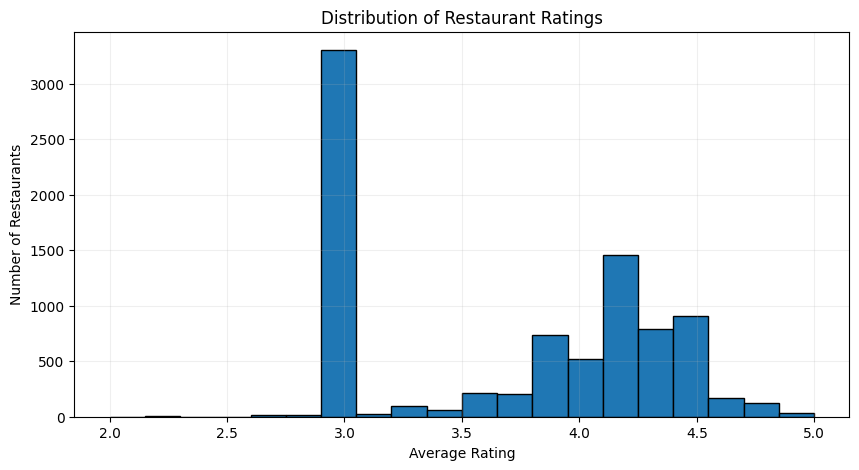

In [8]:
rating_summary = df["Avg ratings"].describe().round(2)
display(rating_summary.to_frame("Value"))

plt.figure(figsize=(10, 5))
plt.hist(df["Avg ratings"], bins=20, edgecolor="black")
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Restaurants")
plt.grid(alpha=0.2)
plt.show()


In [9]:
# Top-rated restaurants
top_rated = (
    df[["Restaurant", "City", "Avg ratings", "Total ratings", "Price", "Food type"]]
    .sort_values(["Avg ratings", "Total ratings"], ascending=[False, False])
    .head(15)
)

display(top_rated)


,Restaurant,City,Avg ratings,Total ratings,Price,Food type
5519,Cafe Kokomo,Mumbai,5.0,50,400.0,"Beverages,Snacks,Desserts,Bakery"
3894,Diamond Market Pizza Jp,Mumbai,5.0,20,600.0,Italian
5424,Get In My Belly,Mumbai,5.0,20,500.0,Indian
5425,The Asian Pavilion,Mumbai,5.0,20,200.0,Asian Chinese
5684,Papacream,Pune,5.0,20,350.0,Ice Cream
5798,Wallonia Waffle Co.,Hyderabad,5.0,20,300.0,Desserts
5799,Splurge - Thickshakes And Milkshakes,Hyderabad,5.0,20,300.0,Desserts Ice Cream Beverages
5800,The Liege Waffles,Hyderabad,5.0,20,300.0,Desserts Bakery
5885,Nivala Apka Apna,Mumbai,5.0,20,200.0,"North Indian,Chinese,Indian"
5936,Tricky Shakes,Bangalore,5.0,20,250.0,"Ice Cream,Beverages"


## 6. Customer Popularity Analysis

,Restaurant,City,Total ratings,Avg ratings,Price,Food type
1819,4M Biryani House,Hyderabad,10000,4.1,250.0,"Biryani,North Indian,Chinese"
90,Grand Hotel,Hyderabad,10000,4.1,300.0,"Biryani,Tandoor,Chinese,Indian,Kebabs,Desserts"
803,Shah Ghouse Cafe & Restaurant,Hyderabad,10000,4.0,350.0,Biryani North Indian Chinese Mughlai Tandoor
4069,Lucky Restaurant,Hyderabad,10000,4.0,300.0,"Biryani,Tandoor,Chinese,North Indian,Desserts,..."
95,Mehfil,Hyderabad,10000,3.9,300.0,"Biryani,Tandoor,Chinese,Indian,Kebabs,Desserts"
106,Bawarchi,Hyderabad,10000,3.9,300.0,"Biryani,Tandoor,Chinese,Indian,Desserts,Kebabs..."
6431,Guru Kripa (Sion West),Mumbai,5000,4.5,300.0,Fast Food
1882,Shah Ghouse Cafe & Restaurant,Hyderabad,5000,4.1,350.0,"Biryani,Chinese,Tandoor,Mughlai,North Indian"
556,Abar Khaboo,Kolkata,5000,4.0,300.0,"Chinese,Biryani,Indian,Oriental"
687,Gulab Wala,Delhi,5000,4.3,350.0,"North Indian,Desserts,South Indian,Street Food..."


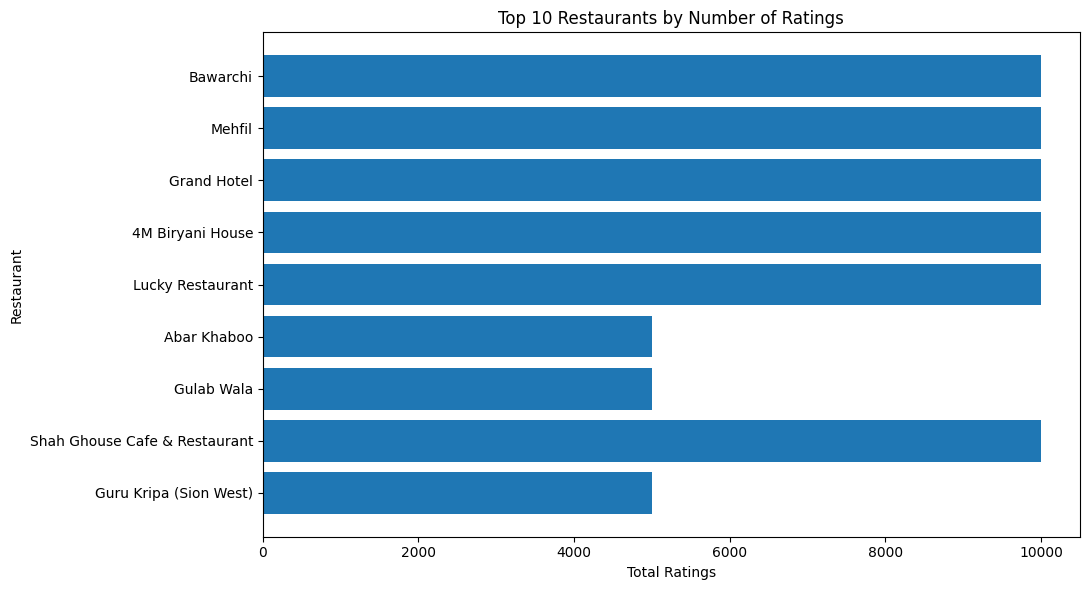

In [10]:
# Restaurants with the highest number of ratings
most_reviewed = (
    df[["Restaurant", "City", "Total ratings", "Avg ratings", "Price", "Food type"]]
    .sort_values("Total ratings", ascending=False)
    .head(15)
)

display(most_reviewed)

plt.figure(figsize=(11, 6))
top10 = most_reviewed.head(10).sort_values("Total ratings")
plt.barh(top10["Restaurant"].astype(str), top10["Total ratings"])
plt.title("Top 10 Restaurants by Number of Ratings")
plt.xlabel("Total Ratings")
plt.ylabel("Restaurant")
plt.tight_layout()
plt.show()


## 7. City and Area Analysis

Number of unique cities: 9


,Restaurants
City,
Kolkata,1346
Mumbai,1277
Chennai,1106
Pune,1090
Hyderabad,1075
Bangalore,946
Ahmedabad,717
Delhi,611
Surat,512


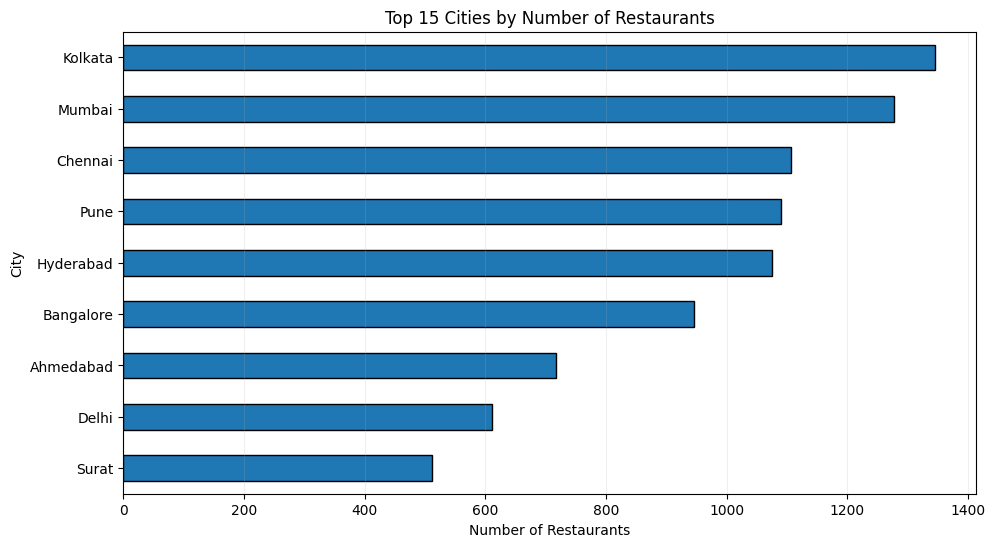

In [11]:
city_counts = df["City"].value_counts()

print("Number of unique cities:", df["City"].nunique())
display(city_counts.head(20).to_frame("Restaurants"))

plt.figure(figsize=(11, 6))
city_counts.head(15).sort_values().plot(kind="barh", edgecolor="black")
plt.title("Top 15 Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")
plt.grid(axis="x", alpha=0.2)
plt.show()


In [12]:
# Area-level concentration
area_counts = df["Area"].value_counts()

print("Number of unique areas:", df["Area"].nunique())
display(area_counts.head(20).to_frame("Restaurants"))


Number of unique areas: 833


,Restaurants
Area,
Rohini,257
Chembur,208
Kothrud,149
Andheri East,135
Navrangpura,132
Indiranagar,130
Kurla,129
Koramangala,124
Bidhannagar,123


## 8. Food Type Analysis

Unique food types: 3734


,Restaurants
Food type,
Indian,389
Chinese,277
North Indian,246
Fast Food,240
South Indian,228
Desserts,106
"Indian,Chinese",106
"North Indian,Chinese",99
Bakery,90


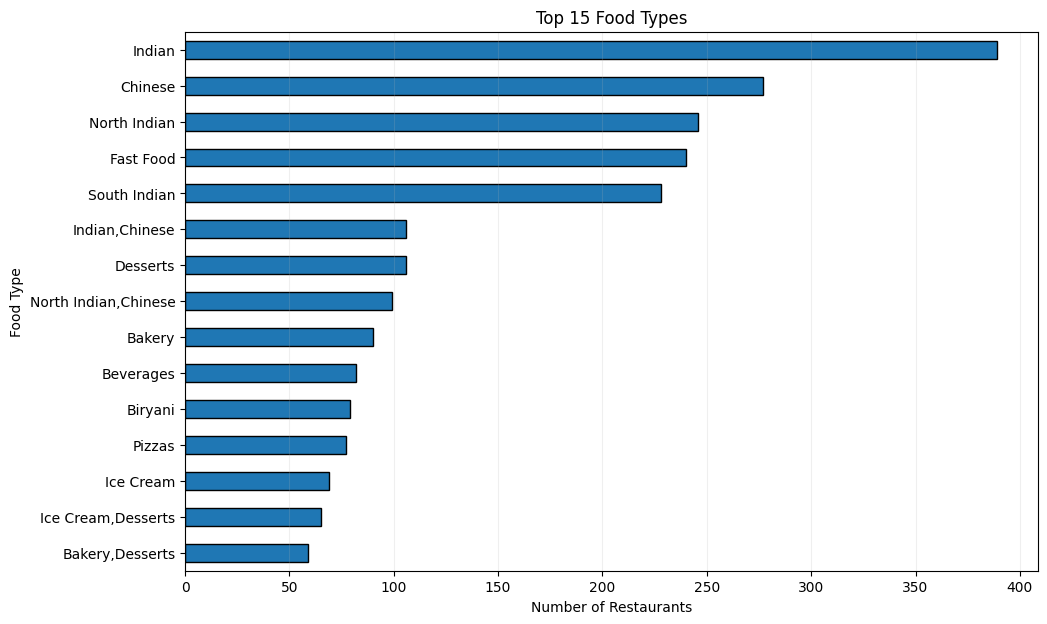

In [13]:
food_counts = df["Food type"].value_counts()

print("Unique food types:", df["Food type"].nunique())
display(food_counts.head(20).to_frame("Restaurants"))

plt.figure(figsize=(11, 7))
food_counts.head(15).sort_values().plot(kind="barh", edgecolor="black")
plt.title("Top 15 Food Types")
plt.xlabel("Number of Restaurants")
plt.ylabel("Food Type")
plt.grid(axis="x", alpha=0.2)
plt.show()


## 9. Delivery Time Analysis

Delivery time statistics:


,Value
count,8680.00
mean,53.97
std,14.29
min,20.00
25%,44.00
50%,53.00
75%,64.00
max,109.00


,Restaurants
Delivery Band,
≤20,1
21–30,215
31–40,1629
41–50,1980
51–60,2172
>60,2683


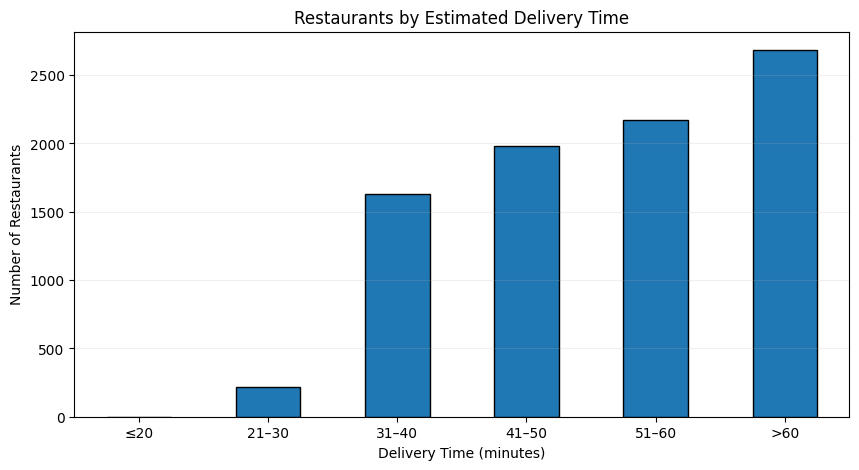

In [14]:
print("Delivery time statistics:")
display(df["Delivery time"].describe().round(2).to_frame("Value"))

delivery_bins = [-np.inf, 20, 30, 40, 50, 60, np.inf]
delivery_labels = ["≤20", "21–30", "31–40", "41–50", "51–60", ">60"]

df["Delivery Band"] = pd.cut(
    df["Delivery time"],
    bins=delivery_bins,
    labels=delivery_labels
)

delivery_band = df["Delivery Band"].value_counts().sort_index()
display(delivery_band.to_frame("Restaurants"))

plt.figure(figsize=(10, 5))
delivery_band.plot(kind="bar", edgecolor="black")
plt.title("Restaurants by Estimated Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)
plt.show()


## 10. Bivariate Analysis

,Price,Avg ratings,Total ratings,Delivery time
Price,1.00,0.11,-0.01,0.08
Avg ratings,0.11,1.00,0.16,-0.15
Total ratings,-0.01,0.16,1.00,-0.08
Delivery time,0.08,-0.15,-0.08,1.00


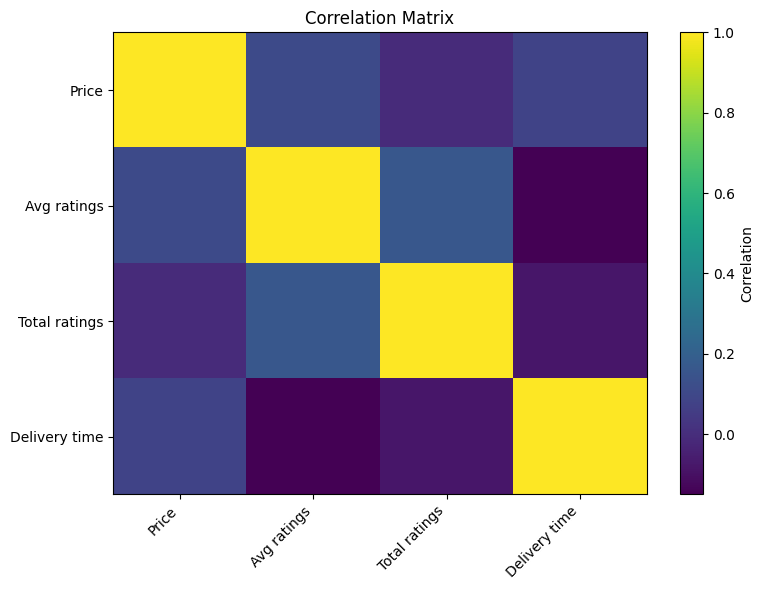

In [15]:
# Correlation matrix for numerical features
corr = df[numeric_cols].corr().round(2)
display(corr)

plt.figure(figsize=(8, 6))
plt.imshow(corr, interpolation="nearest", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


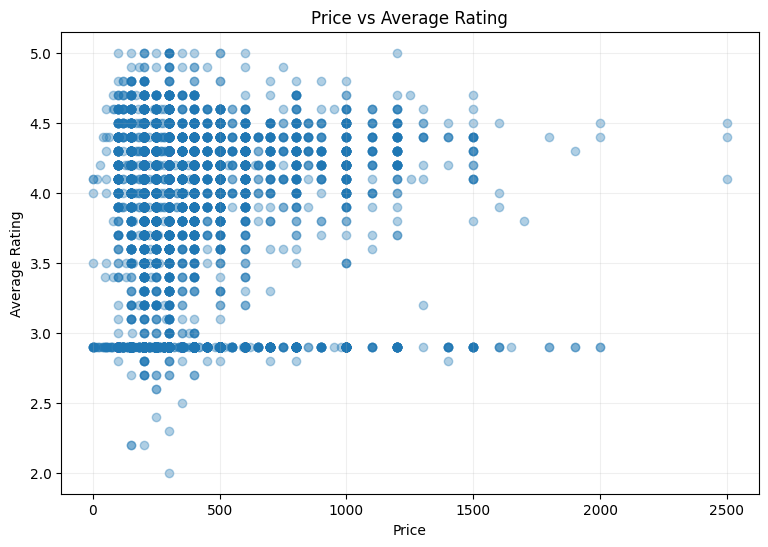

In [16]:
# Price vs rating
plt.figure(figsize=(9, 6))
plt.scatter(df["Price"], df["Avg ratings"], alpha=0.35)
plt.title("Price vs Average Rating")
plt.xlabel("Price")
plt.ylabel("Average Rating")
plt.grid(alpha=0.2)
plt.show()


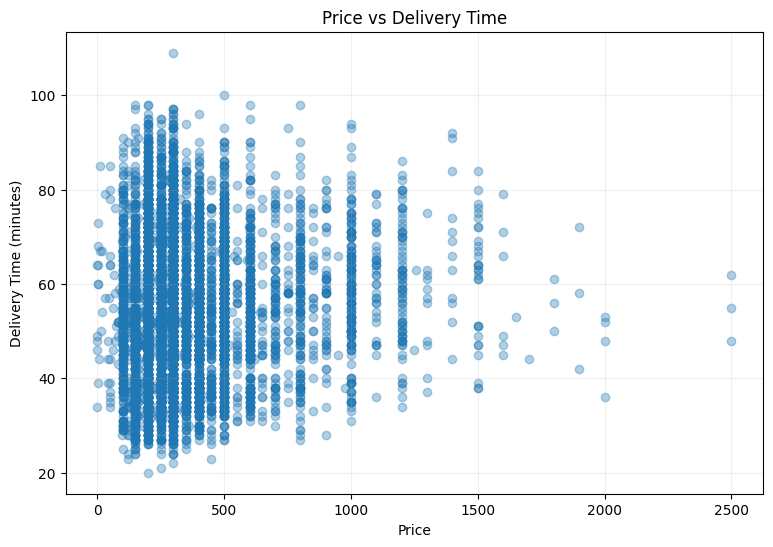

In [17]:
# Price vs delivery time
plt.figure(figsize=(9, 6))
plt.scatter(df["Price"], df["Delivery time"], alpha=0.35)
plt.title("Price vs Delivery Time")
plt.xlabel("Price")
plt.ylabel("Delivery Time (minutes)")
plt.grid(alpha=0.2)
plt.show()


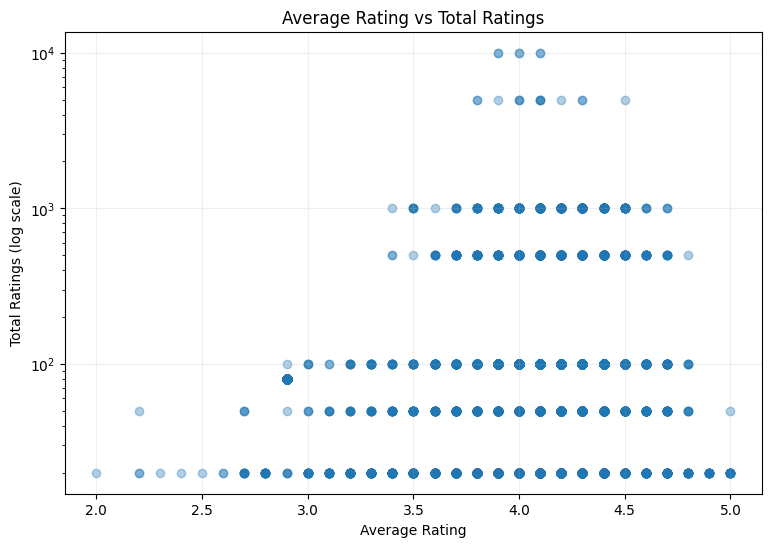

In [18]:
# Ratings vs popularity
plt.figure(figsize=(9, 6))
plt.scatter(df["Avg ratings"], df["Total ratings"], alpha=0.35)
plt.yscale("log")
plt.title("Average Rating vs Total Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Total Ratings (log scale)")
plt.grid(alpha=0.2)
plt.show()


## 11. Grouped Analysis by City

In [19]:
city_analysis = (
    df.groupby("City")
      .agg(
          Restaurants=("ID", "count"),
          Avg_Price=("Price", "mean"),
          Avg_Rating=("Avg ratings", "mean"),
          Avg_Total_Ratings=("Total ratings", "mean"),
          Avg_Delivery_Time=("Delivery time", "mean")
      )
      .sort_values("Restaurants", ascending=False)
)

display(city_analysis.head(20).round(2))


,Restaurants,Avg_Price,Avg_Rating,Avg_Total_Ratings,Avg_Delivery_Time
City,,,,,
Kolkata,1346,362.29,3.70,163.30,67.81
Mumbai,1277,393.79,3.60,118.21,48.32
Chennai,1106,356.25,3.78,161.72,58.97
Pune,1090,353.76,3.55,112.83,55.85
Hyderabad,1075,299.93,3.70,307.23,49.93
Bangalore,946,382.52,3.76,148.52,50.53
Ahmedabad,717,318.13,3.60,103.86,44.71
Delhi,611,333.30,3.53,133.26,50.73
Surat,512,270.17,3.58,117.81,48.48


In [20]:
# Cities with the best average ratings, considering only cities with at least 20 restaurants
city_quality = (
    city_analysis[city_analysis["Restaurants"] >= 20]
    .sort_values("Avg_Rating", ascending=False)
    .head(15)
)

display(city_quality.round(2))


,Restaurants,Avg_Price,Avg_Rating,Avg_Total_Ratings,Avg_Delivery_Time
City,,,,,
Chennai,1106,356.25,3.78,161.72,58.97
Bangalore,946,382.52,3.76,148.52,50.53
Hyderabad,1075,299.93,3.70,307.23,49.93
Kolkata,1346,362.29,3.70,163.30,67.81
Mumbai,1277,393.79,3.60,118.21,48.32
Ahmedabad,717,318.13,3.60,103.86,44.71
Surat,512,270.17,3.58,117.81,48.48
Pune,1090,353.76,3.55,112.83,55.85
Delhi,611,333.30,3.53,133.26,50.73


## 12. Grouped Analysis by Food Type

In [21]:
food_analysis = (
    df.groupby("Food type")
      .agg(
          Restaurants=("ID", "count"),
          Avg_Price=("Price", "mean"),
          Avg_Rating=("Avg ratings", "mean"),
          Avg_Delivery_Time=("Delivery time", "mean")
      )
      .sort_values("Restaurants", ascending=False)
)

display(food_analysis.head(20).round(2))


,Restaurants,Avg_Price,Avg_Rating,Avg_Delivery_Time
Food type,,,,
Indian,389,306.48,3.54,55.52
Chinese,277,340.27,3.41,55.63
North Indian,246,337.51,3.57,52.62
Fast Food,240,256.11,3.56,53.79
South Indian,228,227.87,3.86,52.71
Desserts,106,322.64,3.64,52.48
"Indian,Chinese",106,395.09,3.49,54.21
"North Indian,Chinese",99,392.42,3.75,52.14
Bakery,90,322.77,3.45,55.21


## 13. Outlier Analysis

In [22]:
def outlier_summary(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outliers": len(outliers),
        "Outlier %": len(outliers) / len(data) * 100
    }

outlier_table = pd.DataFrame({
    col: outlier_summary(df, col) for col in numeric_cols
}).T.round(2)

display(outlier_table)


,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outlier %
Price,200.0,400.0,200.0,-100.00,700.00,583.0,6.72
Avg ratings,2.9,4.2,1.3,0.95,6.15,0.0,0.00
Total ratings,50.0,100.0,50.0,-25.00,175.00,995.0,11.46
Delivery time,44.0,64.0,20.0,14.00,94.00,22.0,0.25


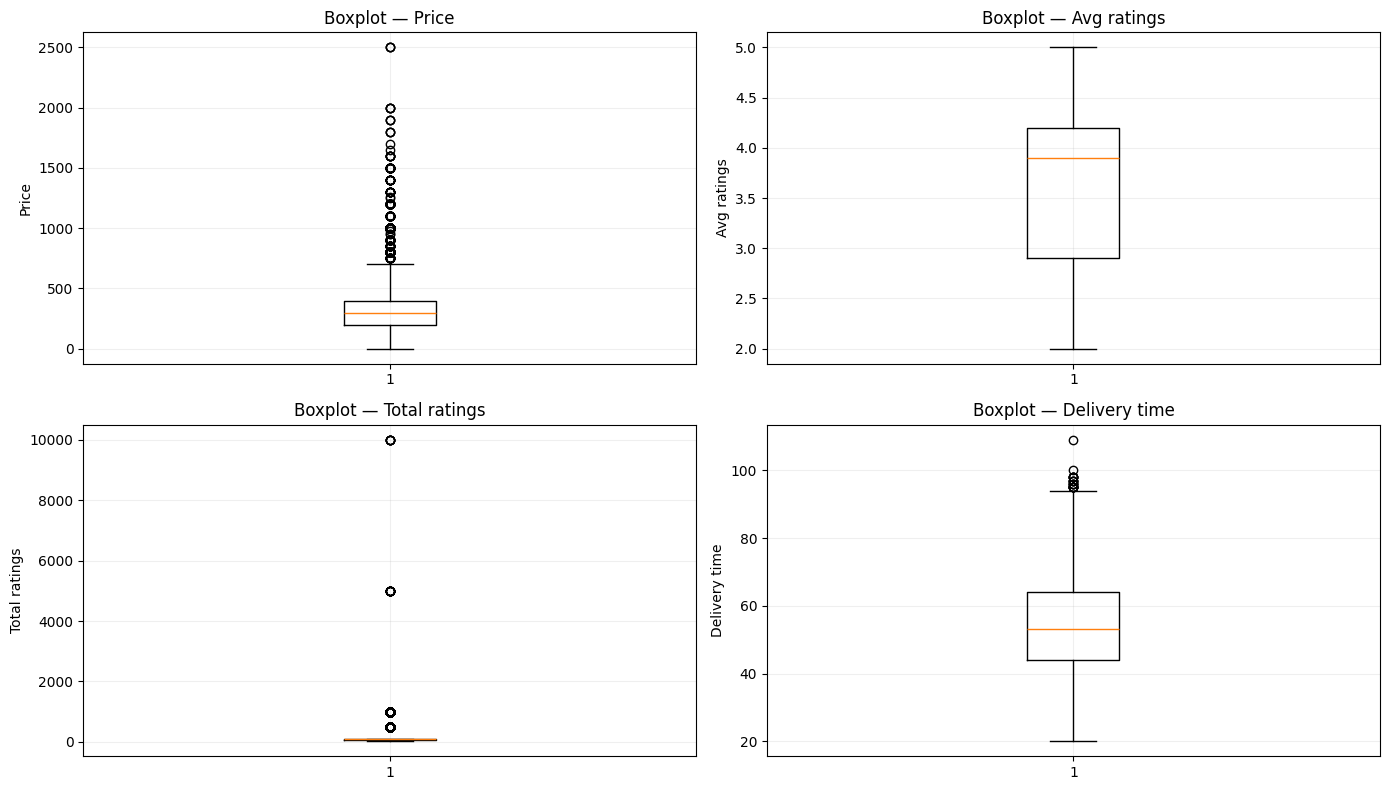

In [23]:
# Boxplots for numerical variables
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(f"Boxplot — {col}")
    ax.set_ylabel(col)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


## 14. Business-Oriented Analysis

In [24]:
# Value-for-money view:
# High rating + relatively low price
value_df = df.copy()

price_median = value_df["Price"].median()
rating_median = value_df["Avg ratings"].median()

value_restaurants = value_df[
    (value_df["Price"] <= price_median) &
    (value_df["Avg ratings"] >= rating_median)
][[
    "Restaurant", "City", "Price", "Avg ratings",
    "Total ratings", "Food type", "Delivery time"
]].sort_values(
    ["Avg ratings", "Total ratings"],
    ascending=[False, False]
)

display(value_restaurants.head(20))


,Restaurant,City,Price,Avg ratings,Total ratings,Food type,Delivery time
5425,The Asian Pavilion,Mumbai,200.0,5.0,20,Asian Chinese,64
5798,Wallonia Waffle Co.,Hyderabad,300.0,5.0,20,Desserts,45
5799,Splurge - Thickshakes And Milkshakes,Hyderabad,300.0,5.0,20,Desserts Ice Cream Beverages,45
5800,The Liege Waffles,Hyderabad,300.0,5.0,20,Desserts Bakery,45
5885,Nivala Apka Apna,Mumbai,200.0,5.0,20,"North Indian,Chinese,Indian",48
5936,Tricky Shakes,Bangalore,250.0,5.0,20,"Ice Cream,Beverages",62
6033,Zorro - Milkshakes And Thickshakes,Hyderabad,300.0,5.0,20,Beverages,46
6297,Fat Tiger,Delhi,300.0,5.0,20,"Pizzas,Chinese,Snacks,Beverages,American",73
6538,Shree Krishna Juice Bar,Pune,150.0,5.0,20,"Juices,Beverages",39
8011,Creams & Bites,Bangalore,200.0,5.0,20,Ice Cream,50


In [25]:
# Fast delivery + high rating
fast_and_good = df[
    (df["Delivery time"] <= df["Delivery time"].median()) &
    (df["Avg ratings"] >= df["Avg ratings"].quantile(0.75))
][[
    "Restaurant", "City", "Price", "Avg ratings",
    "Total ratings", "Food type", "Delivery time"
]].sort_values(
    ["Avg ratings", "Delivery time"],
    ascending=[False, True]
)

display(fast_and_good.head(20))


,Restaurant,City,Price,Avg ratings,Total ratings,Food type,Delivery time
6538,Shree Krishna Juice Bar,Pune,150.0,5.0,20,"Juices,Beverages",39
3894,Diamond Market Pizza Jp,Mumbai,600.0,5.0,20,Italian,43
6930,Snaxx,Mumbai,500.0,5.0,20,Snacks,44
5798,Wallonia Waffle Co.,Hyderabad,300.0,5.0,20,Desserts,45
5799,Splurge - Thickshakes And Milkshakes,Hyderabad,300.0,5.0,20,Desserts Ice Cream Beverages,45
5800,The Liege Waffles,Hyderabad,300.0,5.0,20,Desserts Bakery,45
8439,Keventers Ice Creamery,Kolkata,300.0,5.0,20,"Ice Cream,Desserts",45
5519,Cafe Kokomo,Mumbai,400.0,5.0,50,"Beverages,Snacks,Desserts,Bakery",46
6033,Zorro - Milkshakes And Thickshakes,Hyderabad,300.0,5.0,20,Beverages,46
5885,Nivala Apka Apna,Mumbai,200.0,5.0,20,"North Indian,Chinese,Indian",48


## 15. Key Findings

In [26]:
# Automatically generate a few dataset-level findings
print("KEY FINDINGS")
print("=" * 60)

print(f"1. Dataset contains {len(df):,} restaurant records across {df['City'].nunique():,} cities.")
print(f"2. Average listed price: {df['Price'].mean():.2f}; median price: {df['Price'].median():.2f}.")
print(f"3. Average restaurant rating: {df['Avg ratings'].mean():.2f}.")
print(f"4. Average delivery time: {df['Delivery time'].mean():.2f} minutes.")
print(f"5. Most common city: {df['City'].mode().iloc[0]}.")
print(f"6. Most common food type: {df['Food type'].mode().iloc[0]}.")
print(f"7. Most reviewed restaurant: {df.loc[df['Total ratings'].idxmax(), 'Restaurant']}.")
print(f"8. Highest-rated restaurant record: {df.loc[df['Avg ratings'].idxmax(), 'Restaurant']} "
      f"with rating {df['Avg ratings'].max():.2f}.")


KEY FINDINGS
1. Dataset contains 8,680 restaurant records across 9 cities.
2. Average listed price: 348.44; median price: 300.00.
3. Average restaurant rating: 3.66.
4. Average delivery time: 53.97 minutes.
5. Most common city: Kolkata.
6. Most common food type: Indian.
7. Most reviewed restaurant: Grand Hotel.
8. Highest-rated restaurant record: Diamond Market Pizza Jp with rating 5.00.


## 16. Conclusion

### Overall Insights
This EDA provides a structured view of the Swiggy restaurant ecosystem using pricing, ratings, popularity, food type, geography, and delivery time.

### Questions answered
- Which cities/areas have the largest restaurant presence?
- What price ranges are most common?
- How are restaurant ratings distributed?
- Which restaurants receive the most customer ratings?
- Which food types dominate the dataset?
- What is the typical delivery time?
- Are price, ratings, popularity, and delivery time strongly related?
- Which restaurants appear attractive from a value-for-money perspective?

### Possible Next Steps
1. Build an interactive **Power BI dashboard** from this dataset.
2. Perform statistical hypothesis testing on price/rating relationships.
3. Build a restaurant recommendation system.
4. Predict delivery time using machine learning.
5. Segment restaurants using clustering based on price, rating, popularity, and delivery time.


## Portfolio Project Summary

**Project:** Swiggy Restaurant Exploratory Data Analysis

**Tools:** Python, Pandas, NumPy, Matplotlib, Jupyter Notebook

**Skills Demonstrated:** Data cleaning, data quality checks, descriptive statistics, univariate analysis, bivariate analysis, correlation analysis, outlier detection, categorical analysis, grouped analysis, and business insight generation.
